In [ ]:
# ----- Task 1: Dataset Understanding ----- 
import pandas as pd

In [3]:
df = pd.read_csv('../Data/anime.csv')
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [18]:
print('Dataset information:')
print(df.info())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anime_id    12294 non-null  int64  
 1   name        12294 non-null  object 
 2   genre       12232 non-null  object 
 3   anime_type  12269 non-null  object 
 4   episodes    12294 non-null  object 
 5   rating      12064 non-null  float64
 6   members     12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB
None


In [20]:
print('\n Dataset Shape:')
print(df.shape)


 Dataset Shape:
(12294, 7)


In [22]:
df.head()

,anime_id,name,genre,anime_type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [28]:
# ----- Task 2: Data Cleaning & Preprocessing -----
import numpy as np

df= df.drop_duplicates()

In [29]:
print('missing values before cleaning:')
print(df.isnull().sum())

missing values before cleaning:
anime_id        0
name            0
genre          62
anime_type     25
episodes        0
rating        230
members         0
dtype: int64


In [33]:
# For 'genre', 'type', and 'rating', we can drop the rows where these are missing 
# as imputing them might skew your analysis. 
df = df.dropna(subset=['genre', 'anime_type', 'rating'])

In [34]:
# 3. Fix formatting issues (handling "Unknown" in 'episodes')
# We replace "Unknown" with 0 (or you could use -1 to represent missing numericals), 
# which allows us to safely convert the entire column to integers.
df['episodes'] = df['episodes'].replace('Unknown', 0).astype(int)

In [35]:
# Verify the cleaning
print("\n--- Missing values after cleaning ---")
print(df.isnull().sum())


--- Missing values after cleaning ---
anime_id      0
name          0
genre         0
anime_type    0
episodes      0
rating        0
members       0
dtype: int64


In [41]:
print("\n--- Updated Data Types ---")
print(df.dtypes)


--- Updated Data Types ---
anime_id        int64
name           object
genre          object
anime_type     object
episodes        int64
rating        float64
members         int64
dtype: object


In [43]:

# Display the shape after cleaning to see how many rows were dropped
print("\nCleaned Dataset Shape:", df.shape)


Cleaned Dataset Shape: (12017, 7)


In [44]:
print(f"\nFinal Cleaned Dataset Size: {df.shape[0]} rows and {df.shape[1]} columns.")


Final Cleaned Dataset Size: 12017 rows and 7 columns.


In [46]:
# Check correlation between numerical columns
print("--- Correlation Matrix ---")
correlation_matrix = df[['rating', 'members', 'episodes']].corr()
print(correlation_matrix)


--- Correlation Matrix ---
            rating   members  episodes
rating    1.000000  0.388499  0.088680
members   0.388499  1.000000  0.056101
episodes  0.088680  0.056101  1.000000


In [70]:
print(df.columns.tolist())


['anime_id', 'name', 'genre', 'anime_type', 'episodes', 'rating', 'members']


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

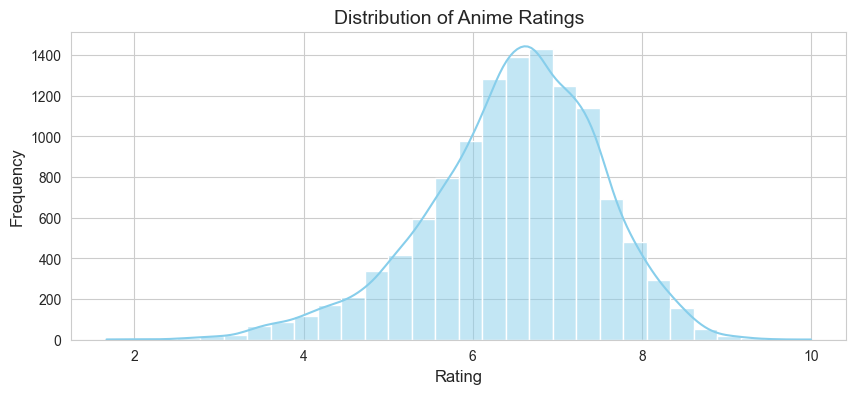

In [54]:
# ----- Task 3: Exploratory Data Analysis (EDA) -----
# histogram of ratings
plt.figure(figsize=(10, 4))
sns.histplot(df['rating'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Anime Ratings', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

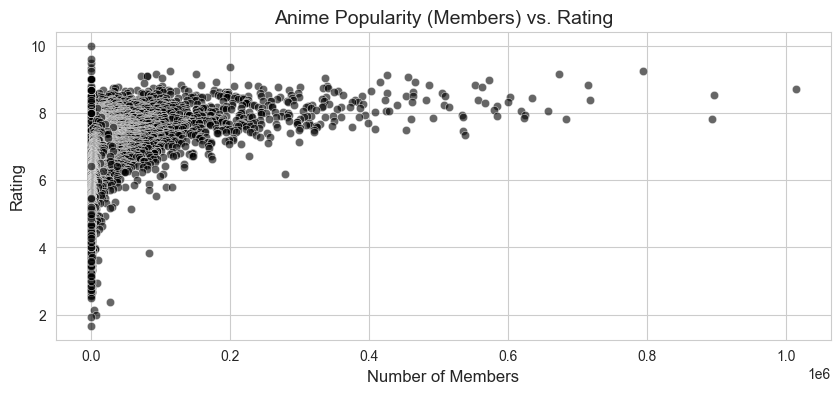

In [58]:
# scatter plot of Members vs Rating
plt.figure(figsize=(10,4))
sns.scatterplot(x='members', y='rating', data=df, alpha=.6,color='black')
plt.title('Anime Popularity (Members) vs. Rating', fontsize=14)
plt.xlabel('Number of Members', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")


C:\Users\prasi\AppData\Local\Temp\ipykernel_18488\997770991.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='name', data=top_10_anime, palette='viridis')


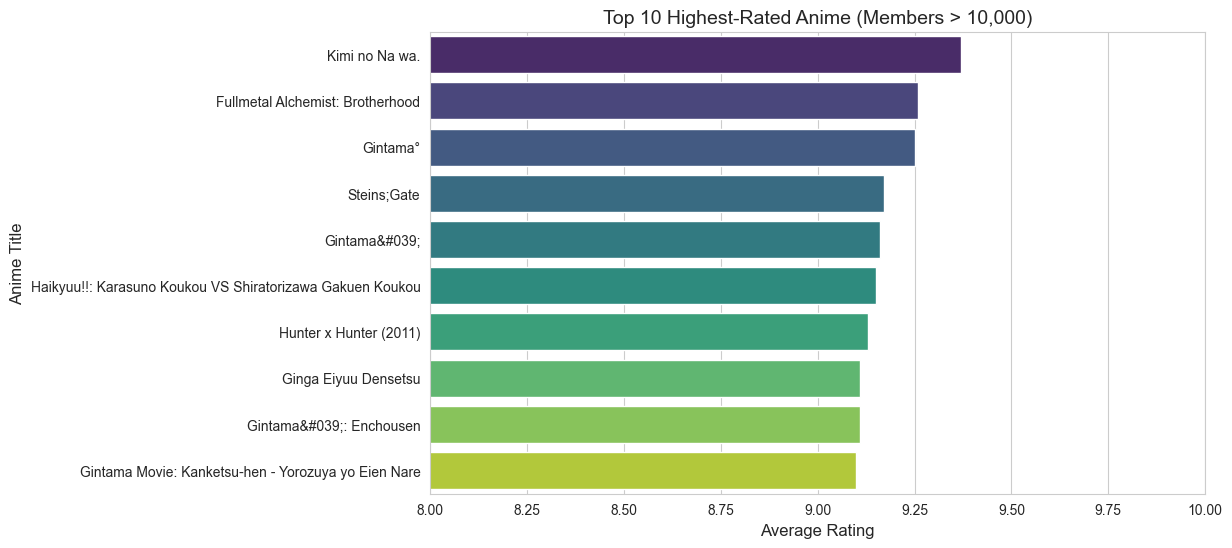

In [65]:
# Filter for anime with > 10,000 members, then get the top 10 by rating
top_10_anime = df[df['members'] > 10000].nlargest(10, 'rating')

plt.figure(figsize=(10, 6))
# Plot horizontal bar chart (x='rating', y='name')
sns.barplot(x='rating', y='name', data=top_10_anime, palette='viridis')

plt.title('Top 10 Highest-Rated Anime (Members > 10,000)', fontsize=14)
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Anime Title', fontsize=12)
# Zooming in on the X-axis slightly makes the rating differences easier to see
plt.xlim(8, 10) 
plt.show()

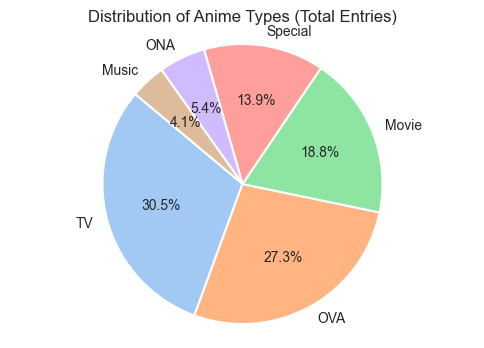

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the total number of entries for each anime type
type_counts = df['anime_type'].value_counts()

# Set up the figure size
plt.figure(figsize=(6, 4))

# Create the pie chart
# - autopct='%1.1f%%' automatically calculates and formats the percentages
# - startangle=140 rotates the chart for better label readability
# - wedgeprops adds a clean white border between the slices
plt.pie(
    type_counts.values, 
    labels=type_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("pastel"),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Add a clear title and ensure the pie chart is a perfect circle
plt.title('Distribution of Anime Types (Total Entries)', fontsize=12,)
plt.axis('equal') 

# Render the plot
plt.show()


C:\Users\prasi\AppData\Local\Temp\ipykernel_18488\2181239985.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='anime_type', order=type_counts_order, palette='muted')


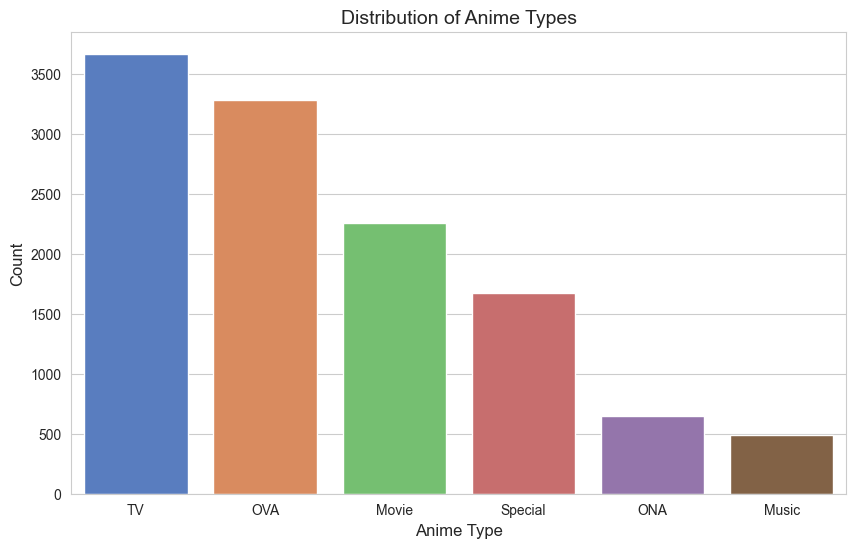

In [71]:
# Chart 2: Distribution of Anime Types
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Extract the index of value counts to order the bars from most to least frequent
type_counts_order = df['anime_type'].value_counts().index

sns.countplot(data=df, x='anime_type', order=type_counts_order, palette='muted')

plt.title('Distribution of Anime Types', fontsize=14)
plt.xlabel('Anime Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

C:\Users\prasi\AppData\Local\Temp\ipykernel_18488\3993149034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='anime_type', y='rating', data=avg_rating_by_type, palette='coolwarm')


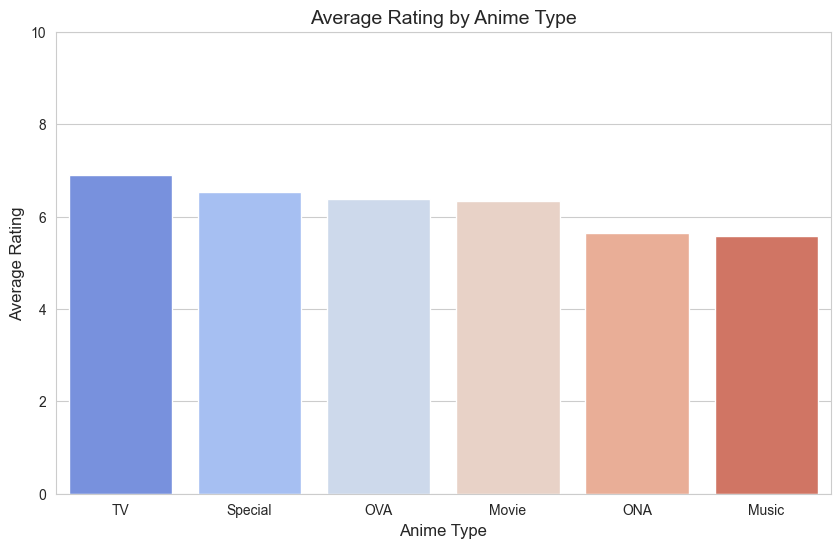

In [72]:
# Chart 3: Average Rating by Anime Type
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Group by 'type', calculate the mean rating, sort descending, and reset index for plotting
avg_rating_by_type = df.groupby('anime_type')['rating'].mean().sort_values(ascending=False).reset_index()

sns.barplot(x='anime_type', y='rating', data=avg_rating_by_type, palette='coolwarm')

plt.title('Average Rating by Anime Type', fontsize=14)
plt.xlabel('Anime Type', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
# Standardize the Y-axis to match the 0-10 rating scale
plt.ylim(0, 10) 
plt.show()

In [74]:
sns.set_style('whitegrid')

In [75]:
# 1. Filter the dataset for the Big 3 franchises
# We use regex to find any row where the name contains One Piece, Bleach, or Naruto
pattern = 'One Piece|Bleach|Naruto'
big3_df = df[df['name'].str.contains(pattern, case=False, na=False)].copy()

In [78]:
big3_df.head()

,anime_id,name,genre,anime_type,episodes,rating,members
74,21,One Piece,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",TV,0,8.58,504862
143,4155,One Piece Film: Strong World,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",Movie,1,8.42,85020
163,12859,One Piece Film: Z,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",Movie,1,8.39,76051
212,31490,One Piece Film: Gold,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",Movie,1,8.32,18642
231,19123,One Piece: Episode of Merry - Mou Hitori no Na...,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",Special,1,8.29,17247


In [79]:
# 2. Create a clean 'franchise' column for grouping
# Because titles look like "Naruto: Shippuuden" or "One Piece Film: Gold", 
# we need a clean label to group them by.
conditions = [
    big3_df['name'].str.contains('One Piece', case=False, na=False),
    big3_df['name'].str.contains('Bleach', case=False, na=False),
    big3_df['name'].str.contains('Naruto', case=False, na=False)
]
choices = ['One Piece', 'Bleach', 'Naruto']
big3_df['franchise'] = np.select(conditions, choices, default='Other')


In [80]:
# 3. Aggregate the data to compare them
# We will calculate the average rating, total popularity (members), and total episodes
big3_stats = big3_df.groupby('franchise').agg({
    'rating': 'mean',
    'members': 'sum',
    'episodes': 'sum',
    'name': 'count' # This counts how many movies/shows exist for the franchise
}).rename(columns={'name': 'total_entries'}).reset_index()

print("--- Big 3 Franchise Statistics ---")
print(big3_stats.to_string(index=False))

--- Big 3 Franchise Statistics ---
franchise   rating  members  episodes  total_entries
   Bleach 7.542857  1278191       372              7
   Naruto 7.348800  2611144       293             25
One Piece 7.585610  1461982        47             41


C:\Users\prasi\AppData\Local\Temp\ipykernel_18488\3242635723.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='franchise', y='rating', data=big3_stats, ax=axes[0], palette='Blues_d')
C:\Users\prasi\AppData\Local\Temp\ipykernel_18488\3242635723.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='franchise', y='members', data=big3_stats, ax=axes[1], palette='Reds_d')
C:\Users\prasi\AppData\Local\Temp\ipykernel_18488\3242635723.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='franchise', y='episodes', data=big3_stats, ax=axes[2]

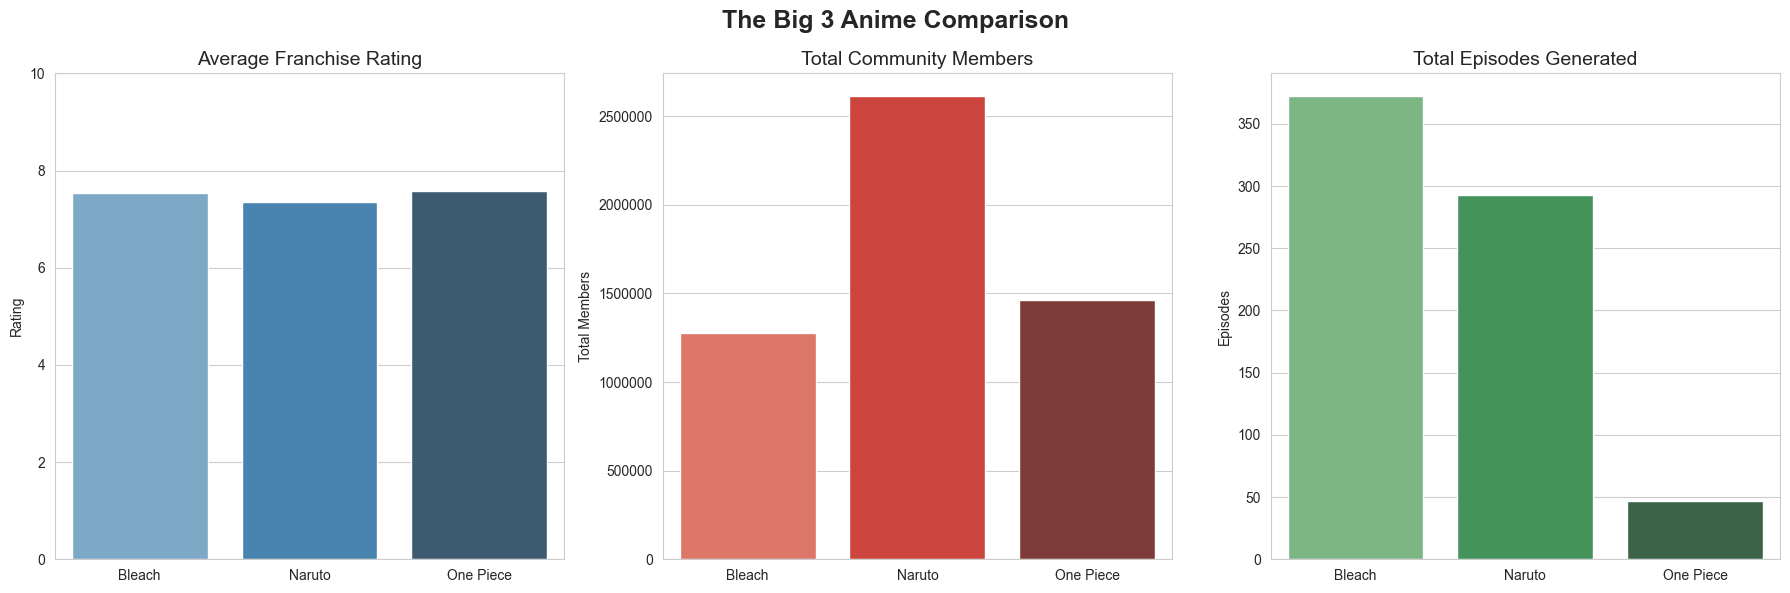

In [91]:
# 4. Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle('The Big 3 Anime Comparison', fontsize=18, fontweight='bold')

# Plot 1: Average Rating
sns.barplot(x='franchise', y='rating', data=big3_stats, ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Franchise Rating', fontsize=14)
axes[0].set_ylim(0, 10)
axes[0].set_ylabel('Rating')
axes[0].set_xlabel('')

# Plot 2: Total Members (Popularity)
sns.barplot(x='franchise', y='members', data=big3_stats, ax=axes[1], palette='Reds_d')
axes[1].set_title('Total Community Members', fontsize=14)
axes[1].set_ylabel('Total Members')
axes[1].set_xlabel('')
# Format Y-axis to show plain numbers instead of scientific notation
axes[1].ticklabel_format(style='plain', axis='y') 

# Plot 3: Total Episodes
sns.barplot(x='franchise', y='episodes', data=big3_stats, ax=axes[2], palette='Greens_d')
axes[2].set_title('Total Episodes Generated', fontsize=14)
axes[2].set_ylabel('Episodes')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

In [94]:
# ----- Task 5: recommendations Engine -----
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1 Handle missing values and  creat the 'tags' column
# We will combine 'genre', 'type' into tags for the recommendation engine.
df['genre'] = df['genre'].fillna('')
df['anime_type'] = df['anime_type'].fillna('')
df['tags'] = df['genre'] + ' ' + df['anime_type']

# reset dataframe index so it aligns with the cosine similarity matrix
df=df.reset_index(drop=True)

In [96]:
#  2. Use CountVectorizer to convert the 'tags' column into a vector matrix
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(df['tags']).toarray()

# 3. Calculate the cosine similarity scores between all anime
similarity = cosine_similarity(vectors)

In [108]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. CRITICAL STEP: Reset the index of your cleaned dataframe
# This ensures our dataframe rows perfectly align with our mathematical matrix
df.reset_index(drop=True, inplace=True)

# 2. Combine Features into 'Tags'
# We merge genre and type into one single string of words for the model to read
df['tags'] = df['genre'].fillna('') + " " + df['anime_type'].fillna('')

# 3. Vectorization (Turn words into numbers)
# CountVectorizer counts the words in 'tags' and creates a map of numbers
cv = CountVectorizer(stop_words='english')
vector_matrix = cv.fit_transform(df['tags'])

# 4. Calculate Cosine Similarity
# This mathematically measures the angle between anime vectors to find matches
similarity = cosine_similarity(vector_matrix)

# 5. Build the Recommendation Function
def recommend_anime(anime_name):
    # Find the sequential row position of the given anime title
    try:
        anime_row = df[df['name'].str.lower() == anime_name.lower()].index[0]
    except IndexError:
        print(f"❌ Anime '{anime_name}' not found in the dataset. Check spelling!")
        return

    # Fetch the similarity scores for this specific anime row
    similarity_scores = similarity[anime_row]

    # Pair scores with their original row numbers, sort them highest to lowest,
    # and grab the top 5 matches (skipping index 0 because that is the anime itself)
    top_matches = sorted(list(enumerate(similarity_scores)), key=lambda x: x[1], reverse=True)[1:6]

    # Print the final results beautifully
    print(f"\n🎯 Top 5 Recommendations for '{anime_name}':")
    print("-" * 50)
    for rank, item in enumerate(top_matches, 1):
        matched_row_index = item[0]
        title = df.iloc[matched_row_index]['name']
        genres = df.iloc[matched_row_index]['genre']
        anime_type = df.iloc[matched_row_index]['anime_type']
        
        print(f"{rank}. {title}")
        print(f"   Format: {anime_type} | Genres: {genres}\n")

# 6. Test the Engine!
recommend_anime('One Piece')


🎯 Top 5 Recommendations for 'One Piece':
--------------------------------------------------
1. One Piece: Episode of Merry - Mou Hitori no Nakama no Monogatari
   Format: Special | Genres: Action, Adventure, Comedy, Drama, Fantasy, Shounen, Super Power

2. One Piece: Episode of Nami - Koukaishi no Namida to Nakama no Kizuna
   Format: Special | Genres: Action, Adventure, Comedy, Drama, Fantasy, Shounen, Super Power

3. One Piece: Episode of Sabo - 3 Kyoudai no Kizuna Kiseki no Saikai to Uketsugareru Ishi
   Format: Special | Genres: Action, Adventure, Comedy, Drama, Fantasy, Shounen, Super Power

4. Shingeki no Kyojin
   Format: TV | Genres: Action, Drama, Fantasy, Shounen, Super Power

5. Digimon Frontier
   Format: TV | Genres: Action, Adventure, Comedy, Drama, Fantasy, Shounen



In [110]:
# user input
user_input = input("Enter an anime name to get recommendations: ")
recommend_anime(user_input)


❌ Anime 'Hunter Hunter' not found in the dataset. Check spelling!
